# Homework 7

## Your Name Here (or your names here if you are pair programming)

Student Name: Lily Nguyen

Student UT EID: lmn934

---

Partner Name: John "Jack" Mayberry

Partner UT EID: jmm23398

---

Date Created: Wednesday, July 16th, 2025

Date Last Modified: Saturday, July 19th, 2025

---

Total Points 20. 



## Support Vector Machine 

In [118]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [119]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [120]:
# data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = heart_df[['Age', 'Sex', 'Chol']]
y = heart_df['Target'].map({'Yes': 1.0, 'No': 0.0})

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train_svm.shape, X_test_svm.shape, y_train_svm.shape, y_test_svm.shape)

# scale
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

(242, 3) (61, 3) (242,) (61,)


In [121]:
# Import the necessary packages and create an SVM model
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# establish and fit the model
svm_model = SVC()
svm_model.fit(X_train_svm, y_train_svm)

# run the model on the train/test data and determine the accuracy
y_pred_svm = svm_model.predict(X_test_svm)
print("Predicted values:\n", y_pred_svm)
print()
print("Test values:\n", y_test_svm.to_numpy())
print()
print("Accuracy Score:", accuracy_score(y_test_svm, y_pred_svm))

Predicted values:
 [1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 0. 1. 0. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0.]

Test values:
 [0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0.
 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1.]

Accuracy Score: 0.6065573770491803


This model proved to be somewhat accurate at predicting the target values, with a 0.607 accuracy. This is more effective than random sampling, but can certainly be improved.

# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [122]:
# Calculate the accuracy, precision, recall, and F1

# accuracy
print("Accuracy Score:", accuracy_score(y_test_svm, y_pred_svm))
print()

# print the classification report using the library method
from sklearn.metrics import classification_report
print(classification_report(y_test_svm,y_pred_svm))

Accuracy Score: 0.6065573770491803

              precision    recall  f1-score   support

         0.0       0.57      0.69      0.62        29
         1.0       0.65      0.53      0.59        32

    accuracy                           0.61        61
   macro avg       0.61      0.61      0.61        61
weighted avg       0.61      0.61      0.60        61



Without further changes to the model, the SVM is only somewhat effective.

# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



In [123]:
# manually split the df for training and verify the shape of the matrices

# map target to 1 / 0
heart_df['Target'] = heart_df['Target'].map({'Yes':1,'No':0})

# train/test split the data
train_size = int(0.8 * len(heart_df))
train_set = heart_df[:train_size]
test_set = heart_df[train_size:]

# features and target
features = ['Age', 'Sex', 'Chol']
target = ['Target']
num_features = len(features)

# split dataset train/test 80/20
X_train = train_set[features].to_numpy(dtype=float)
X_test = test_set[features].to_numpy(dtype=float)
y_train = train_set[target].to_numpy(dtype=float).ravel()
y_test = test_set[target].to_numpy(dtype=float).ravel()

# standardize X_train and X_test
mean_train = X_train.mean(axis=0)
std_train  = X_train.std(axis=0)

X_train = (X_train - mean_train) / std_train
X_test  = (X_test  - mean_train) / std_train

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(f'Train %: {X_train.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')
print(f'Test %: {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0]):.0%}')

(242, 3)
(61, 3)
(242,)
(61,)
Train %: 80%
Test %: 20%


In [124]:
def compute_cost(X, y, W, regularization_factor):
    '''
    Calculate the hinge loss
    '''
    n = X.shape[0]
    distances = 1 - y * (np.dot(X, W))
    
    distances[distances < 0] = 0 
    
    hinge_loss = regularization_factor * (np.sum(distances) / n)
    return (1 / 2 * np.dot(W, W) + hinge_loss)

def calculate_gradient(X, y, W, regularization_factor):
    '''
    Calculate the gradient descent
    '''
    if type(y) == np.float64:
        y = np.array([y])
        X = np.array([X])
        
    distance = 1 - (y * np.dot(X, W))
    
    dw = np.zeros(len(W))
    
    for ind, d in enumerate(distance):
        
        if (d < 0):
            di = W
        else:
            di = W - (regularization_factor * y[ind] * X[ind])
            
            
        dw += di
    
    dw = dw/len(y)
    
    return dw

In [125]:
# establish the parameters and run the model
weights = np.zeros(3)

num_iterations = 100
learning_rate = 0.05
regularization = 0.01

cost_list = []

for i in range(0, num_iterations):
    
    cost = compute_cost(X_train, y_train, weights, regularization)
    
    print("Epoch", i + 1, "Cost is:", cost, "weights", weights)
    
    cost_list.append(cost)
    
    grad = calculate_gradient(X_train, y_train, weights, regularization)
    
    weights = weights - learning_rate * grad

Epoch 1 Cost is: 0.01 weights [0. 0. 0.]
Epoch 2 Cost is: 0.009999817339650538 weights [6.23969275e-05 6.84675827e-05 2.80358872e-05]
Epoch 3 Cost is: 0.009999652488685153 weights [1.21674009e-04 1.33511786e-04 5.46699800e-05]
Epoch 4 Cost is: 0.00999950371068889 weights [1.77987236e-04 1.95303780e-04 7.99723681e-05]
Epoch 5 Cost is: 0.009999369438547264 weights [0.00023148 0.00025401 0.00010401]
Epoch 6 Cost is: 0.009999248257939445 weights [0.00028231 0.00030977 0.00012685]
Epoch 7 Cost is: 0.009999138892440891 weights [0.00033059 0.00036275 0.00014854]
Epoch 8 Cost is: 0.009999040190078443 weights [0.00037646 0.00041308 0.00016915]
Epoch 9 Cost is: 0.009998951111196336 weights [0.00042003 0.0004609  0.00018873]
Epoch 10 Cost is: 0.009998870717505232 weights [0.00046143 0.00050632 0.00020733]
Epoch 11 Cost is: 0.009998798162199014 weights [0.00050075 0.00054947 0.000225  ]
Epoch 12 Cost is: 0.00999873268103515 weights [0.00053811 0.00059046 0.00024178]
Epoch 13 Cost is: 0.00999867358

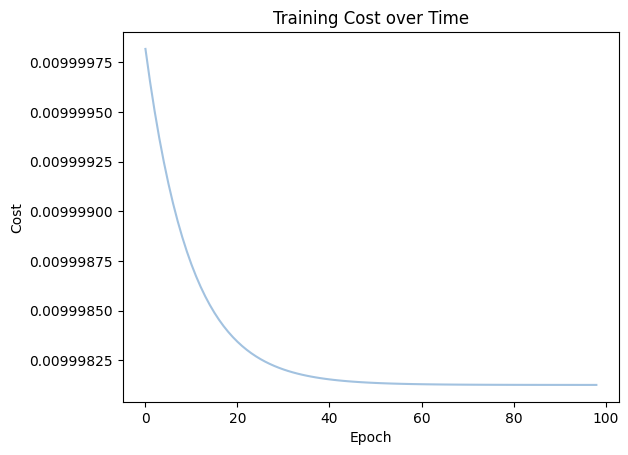

In [126]:
# plot the cost for each training epoch
plt.plot(cost_list[1:], color="#A2C2E0")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Cost over Time")
plt.show()

In [127]:
# run the manual implementation to predict the test set
def predict_svm(weights, X):
    scores = X.dot(weights)
    return np.where(scores >= 0, 1, 0)

# compare with the library implementation
print("Manual Implementation:")
print("Accuracy Score:", accuracy_score(y_test, predict_svm(weights, X_test)))
print(classification_report(y_test,predict_svm(weights, X_test)))

print("Library Implementation:")
print("Accuracy Score:", accuracy_score(y_test_svm, y_pred_svm))
print(classification_report(y_test_svm, y_pred_svm))

Manual Implementation:
Accuracy Score: 0.6721311475409836
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66        29
         1.0       0.69      0.69      0.69        32

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61

Library Implementation:
Accuracy Score: 0.6065573770491803
              precision    recall  f1-score   support

         0.0       0.57      0.69      0.62        29
         1.0       0.65      0.53      0.59        32

    accuracy                           0.61        61
   macro avg       0.61      0.61      0.61        61
weighted avg       0.61      0.61      0.60        61



The manual implementation resulted in a higher accuracy than the library implementation (0.672 > 0.607). Precision, recall, and F1 all saw an increase with the manual implementation. This could be due to the standardization method, or possible overfitting.

# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [128]:
# Import Logistic Regression and compare its result with the SVM model
from sklearn.linear_model import LogisticRegression

# instantiate and run the logistic regression model
model_logr = LogisticRegression()
model_logr.fit(X_train,y_train)
y_pred_logr = model_logr.predict(X_test)

# print results
print("Logistic Regression:", accuracy_score(y_test, y_pred_logr))
print(classification_report(y_test, y_pred_logr))

# use the manual implementation as it's more accurate
print("SVM:", accuracy_score(y_test, predict_svm(weights, X_test)))
print(classification_report(y_test, predict_svm(weights, X_test)))

Logistic Regression: 0.6229508196721312
              precision    recall  f1-score   support

         0.0       0.59      0.69      0.63        29
         1.0       0.67      0.56      0.61        32

    accuracy                           0.62        61
   macro avg       0.63      0.63      0.62        61
weighted avg       0.63      0.62      0.62        61

SVM: 0.6721311475409836
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66        29
         1.0       0.69      0.69      0.69        32

    accuracy                           0.67        61
   macro avg       0.67      0.67      0.67        61
weighted avg       0.67      0.67      0.67        61



The manual implementation of the SVM model resulted in a more accurate predication of the test set than of the logistic regression model.

##### Precision

Logistic regression resulted in an average precision of 0.63, while SVM resulted in an average of 0.67. Logistic regression was noticably more capable of predicting 1.0 values than 0.0.

##### Recall

Here, logistic regression resulted in an average recall of 0.63, while SVM resulted in an average of 0.67. Logistic regression struggles at 1.0 recall, while SVM succeeds: SVM 1.0 recall = 0.69.

##### F1-score

Logistic regression's average F1-score is 0.62, while SVM's is 0.67. Logistic regression is stronger for 0.0 values than 1.0, while SVM's strength is the inverse.

# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [129]:
# establish a list of kernel parameters
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

# iterate through the kernels and determine which is most effective
for kernel in kernels:
    model_k = SVC(kernel=kernel)
    model_k.fit(X_train, y_train)
    y_pred_k = model_k.predict(X_test)

    acc = model_k.score(X_test, y_test)
    results[kernel] = acc
    
    print(f"Kernel: {kernel}, Accuracy: {acc}")

Kernel: linear, Accuracy: 0.6065573770491803
Kernel: poly, Accuracy: 0.4098360655737705
Kernel: rbf, Accuracy: 0.5081967213114754
Kernel: sigmoid, Accuracy: 0.6229508196721312


After testing different kernels, sigmoid is the most accurate for this dataset / training scenario. Next, we'll compare the SVM implementation with and without this parameter.

In [130]:
# without kernel
print("Results from initial library implementation:")
print(classification_report(y_test_svm, y_pred_svm))

# with sigmoid kernel
print("Results from sigmoid kernel implementation:")
model = SVC(kernel = 'sigmoid')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = model.score(X_test, y_test)

print(classification_report(y_test, y_pred))

Results from initial library implementation:
              precision    recall  f1-score   support

         0.0       0.57      0.69      0.62        29
         1.0       0.65      0.53      0.59        32

    accuracy                           0.61        61
   macro avg       0.61      0.61      0.61        61
weighted avg       0.61      0.61      0.60        61

Results from sigmoid kernel implementation:
              precision    recall  f1-score   support

         0.0       0.59      0.66      0.62        29
         1.0       0.66      0.59      0.62        32

    accuracy                           0.62        61
   macro avg       0.62      0.62      0.62        61
weighted avg       0.63      0.62      0.62        61



We see a very marginal increase in accuracy by implementing the sigmoid kernel. When comparing the results, we see a marginal increase in precision for both 0.0 and 1.0 values, a notable increase in 1.0 recall with a small decrease for 0.0 values, and an increase in F1-score for 1.0 predictions.

This implementation serves to marginally improve the SVM model for this dataset / training scenario.